# Project: Bermudan Swaption Pricing in the Hull-White Model using the Longstaff-Schwartz Method (LSM)

# Part 1: Theoretical Background & Model Setup

## 1.1 Hull-White Model Parameters & Zero-Coupon Bond Pricing
The Hull-White short rate model assumes that the instantaneous risk-free interest rate $r_t$ under the risk-neutral pricing measure follows the Stochastic Differential Equation (SDE):
$$dr_t = (\theta(t) - a r_t) dt + \sigma dW_t$$
Where:
* $a$ is the speed of mean reversion, dictating how fast the interest rate returns to its long-term average level.
* $\sigma$ is the instantaneous volatility coefficient parameter.
* $\theta(t)$ is a deterministic function calibrated to fit the initial term structure of interest rates observed in the market.

Under the assumption of a flat initial yield curve profile $r_0$, the pricing of a Zero-Coupon Bond (ZCB) $P(t,T)$ maturing at time $T$, viewed from time $t$, reduces to the exact analytical formula:
$$P(t,T) = A(t,T) \exp(-B(t,T) r_t)$$
where the operational coefficients are explicitly defined as:
$$B(t,T) = \frac{1 - e^{-a(T-t)}}{a}$$
$$\ln A(t,T) = -r_0(T-t) + r_0 B(t,T) - \frac{\sigma^2}{4a}(1 - e^{-2at})B(t,T)^2$$

## 1.2 Interest Rate Swaps (IRS), Moneyness, and Swaption Payoffs

### What is an Interest Rate Swap (IRS)?
An Interest Rate Swap (IRS) is a multi-period financial contract between two counterparties to exchange interest rate cash flows based on a specified principal amount (Notional). Typically, one party pays a **Fixed Rate** (constant over time) while the other party pays a **Floating Rate** (which changes dynamically according to market reference indices, modeled here by the short rate $r_t$).

### Understanding Option Moneyness: ITM, ATM, and OTM
Moneyness describes the relative position of the current market interest rate ($r_t$) with respect to the contract fixed strike rate ($K$). It determines whether exercising the option right now would generate a financial profit:

* **In-The-Money (ITM):** A state where the option possesses a positive intrinsic value. For our **Payer Swaption**, the contract is ITM when the simulated short rate is strictly greater than the strike ($r_t > K$). Executing the option at this node yields an immediate positive cash payoff. *In the Longstaff-Schwartz algorithm, regression is performed strictly on ITM paths to optimize efficiency.*
* **At-The-Money (ATM):** A state where the current market rate equals the strike rate ($r_t = K$). The immediate payoff is exactly zero.
* **Out-The-Money (OTM):** A state where the option has no intrinsic value. For a Payer Swaption, this happens when the market rate falls below the strike ($r_t < K$). Exercising the contract would result in a loss, so the payoff is floored at zero.

### Swaption Types and Framework Definitions
A Swaption (Swap Option) grants the holder the right, but not the obligation, to enter into an underlying Interest Rate Swap at a future date. Depending on the cash flow direction, we define two primary contract setups:

1. **Payer Swaption:**
   Grants the holder the right to enter a swap as a **fixed-rate payer** and a floating-rate receiver. The immediate cash payoff at exercise time $t$ is explicitly defined as:
$$\text{Payoff}_{\text{Payer}}(t) = \left( \sum_{T_i > t} \alpha_i (r_t - K) P(t, T_i) \right)_+$$
   *Economic Intention:* This contract becomes highly valuable (**In-The-Money**) if market interest rates rise significantly above the strike $K$, allowing the holder to pay a cheap fixed rate while receiving high floating interest payments.

2. **Receiver Swaption:**
   Grants the holder the right to enter a swap as a **floating-rate payer** and a **fixed-rate receiver**. The immediate cash payoff at exercise time $t$ is explicitly defined as:
$$\text{Payoff}_{\text{Receiver}}(t) = \left( \sum_{T_i > t} \alpha_i (K - r_t) P(t, T_i) \right)_+$$
   *Economic Intention:* This contract becomes valuable (**In-The-Money**) in a falling interest rate environment, allowing the holder to lock in a high fixed income stream while paying low floating market rates.

Where the constituent mathematical variables are defined as:
* $(\cdot)_+$ is the standard positive part operator $\max(\cdot, 0)$, representing option optionality.
* $r_t$ is the simulated instantaneous short rate value evaluated at the exercise decision time $t$.
* $K$ is the contract fixed strike interest rate agreed upon at inception ($2.0\%$).
* $\alpha_i$ is the year fraction accrual factor for the $i$-th swap payment period (assumed to be $1.0$ for annual periods).
* $P(t, T_i)$ is the analytical price of a Zero-Coupon Bond observed at time $t$ and maturing at the future swap payment date $T_i$.

**Project Scope Selection:** In this project, we explicitly select and implement the valuation of a **Payer Swaption**. A Payer Swaption becomes highly in-the-money and valuable when market interest rates rise significantly above the strike $K$. This selection provides an ideal scenario framework to contrast path-dependent exercise mechanics against static exercise profiles.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analytical_zcb(t, T, r_current, a, sigma, r0):
    """
    Computes the analytical price of a Zero-Coupon Bond P(t, T) in the Hull-White model.
    Inputs:
        t         : current evaluation time (years)
        T         : maturity date of the bond (years)
        r_current : short rate value at the current evaluation time t
        a         : speed of mean reversion parameter
        sigma     : volatility coefficient parameter
        r0        : flat initial yield curve baseline
    Returns:
        Bond price as a numerical float representing a fraction of face value.
    """
    # If evaluation time matches maturity, the contract pays out exactly 1.0 immediately
    if np.isclose(t, T):
        return 1.0

    # Calculate the B(t,T) factor representing interest rate sensitivity
    B_t_T = (1.0 - np.exp(-a * (T - t))) / a

    # Calculate the log of the A(t,T) factor adjusted for the flat yield profile configuration
    ln_A_t_T = -r0 * (T - t) + r0 * B_t_T - (sigma**2 / (4.0 * a)) * (1.0 - np.exp(-2.0 * a * t)) * (B_t_T**2)

    # Return the final recombined value according to the exact pricing equation structure
    return np.exp(ln_A_t_T) * np.exp(-B_t_T * (r_current - r0))

## 1.3 Monte Carlo Short Rate Path
To approximate interest rate profiles under a continuous stochastic framework, we implement the Euler-Maruyama simulation scheme across a fine time grid:
$$r_{t+\Delta t} = r_t + a(r_0 - r_t)\Delta t + \sigma \sqrt{\Delta t} Z$$
where $Z \sim N(0,1)$ represents independent standard normal random variables.

In [ ]:
def simulate_hull_white(N_paths, N_steps, T_max, a, sigma, r0):
    """
    Generates a matrix of short rate paths using the Euler-Maruyama discretization scheme.
    Inputs:
        N_paths : total number of independent scenario paths to simulate
        N_steps : total number of discrete time subdivisions across the horizon
        T_max   : maximum length of the simulation horizon (years)
        a, sigma, r0 : Hull-White model parameters
    Returns:
        t_grid  : 1D array of time coordinates from 0 to T_max
        r       : 2D array of short rates (shape: N_paths x N_steps + 1)
    """
    # Calculate the size of each small discrete time step increment
    dt = T_max / N_steps
    # Generate the sequential array of time grid points
    t_grid = np.linspace(0, T_max, N_steps + 1)
    # Pre-allocate memory for the path storage array matrix
    r = np.zeros((N_paths, N_steps + 1))
    # Enforce the initial boundary condition where every scenario starts at r0
    r[:, 0] = r0

    # Progress step-by-step through the entire time matrix grid
    for i in range(N_steps):
        # Draw a vector of independent random standard normal samples for all paths
        Z = np.random.standard_normal(N_paths)
        # Apply the discretized stochastic differential equation to propagate to step i+1
        r[:, i+1] = r[:, i] + a * (r0 - r[:, i]) * dt + sigma * np.sqrt(dt) * Z

    return t_grid, r

def get_payer_swap_payoff(r_at_t, t, payment_dates, K, a, sigma, r0):
    """
    Computes the financial cash payoff of a Payer Interest Rate Swap at exercise time t.
    Inputs:
        r_at_t        : vector or value of short rates at decision time t
        t             : early exercise decision time (years)
        payment_dates : list of scheduled annual payment legs for the underlying swap
        K             : fixed strike interest rate parameter
    Returns:
        The immediate positive intrinsic option value vector.
    """
    # Define an annual payment interval accrual fraction factor
    alpha = 1.0
    val = 0.0
    # Iterate through all settlement contract payment dates
    for Ti in payment_dates:
        # Only swap cash flows occurring in the future relative to time t are physically exchanged
        if Ti > t:
            # Add the discounted payment leg value (Floating Rate minus Fixed Strike K)
            val += alpha * (r_at_t - K) * analytical_zcb(t, Ti, r_at_t, a, sigma, r0)
    # Apply the standard positive option payoff floor constraint via the maximum operator
    return np.maximum(val, 0)

# Part 2: Valuation Engines Framework

## 2.1 European Swaption Valuation via Standard Monte Carlo
Since a European swaption can only be exercised at a single, fixed contract date ($T_{\text{ex}} = 1.0$ year), its pricing does not require path-dependent decision trees. We can value it using a standard forward Monte Carlo approach:
1. Simulate short rate values directly to Year 1.
2. Evaluate the standalone Payer Swap payoff at Year 1.
3. Discount the payoff back to Year 0 using the risk-neutral initial discounting rate.
4. Calculate the cross-sectional mean across all simulation paths.

## 2.2 Bermudan Swaption Valuation via Longstaff-Schwartz Backward Induction
A Bermudan swaption introduces early exercise opportunities at multiple anniversary windows (Years 1, 2, 3, 4). To value this path-dependent option correctly without forward-looking bias, we apply the **Longstaff-Schwartz Method (LSM)** using backward induction and ordinary least squares (OLS) polynomial regression:
* We start at the terminal decision date (Year 4) and record the initial raw payoffs.
* We step backward to the previous anniversary date. For all paths that are currently *In-The-Money* (ITM), we regress the downstream realized discounted cash flows ($Y$) against the current short rate state variable ($X = r_t$).
* The fitted quadratic polynomial provides the conditional expectation function, establishing the estimated **Continuation Value**.
* Early exercise is triggered on a path if and only if: $\text{Immediate Payoff} > \text{Estimated Continuation Value}$.

In [ ]:
def price_european_swaption(r0_val, K_val, N_paths=5000):
    """
    Prices a European Payer Swaption using standard forward Monte Carlo simulation.
    Exercise is fixed strictly at the end of Year 1 (Time step 20).
    """
    N_steps, T_max = 100, 5.0
    a, sigma = 0.1, 0.015

    # EXPLANATION OF PAYMENT DATES:
    # Our option expires at the end of Year 1. If we exercise it, we enter a swap
    # contract that exchanges cash at the end of Years 1, 2, 3, 4, and 5.
    # The 'if Ti > t:' filter below will automatically discard Year 1.0 (since 1.0 > 1.0 is False),
    # meaning we correctly only evaluate future cash flows from Years 2, 3, 4, and 5.
    payment_dates = [1.0, 2.0, 3.0, 4.0, 5.0]
    euro_exercise_idx = 20 # Step 20 corresponds exactly to Year 1.0

    # 1. Generate interest rate paths up to Year 5
    t_grid, r_paths = simulate_hull_white(N_paths, N_steps, T_max, a, sigma, r0_val)

    # 2. Calculate the swap payoff strictly at Year 1
    euro_payoffs = get_payer_swap_payoff(r_paths[:, euro_exercise_idx], t_grid[euro_exercise_idx], payment_dates, K_val, a, sigma, r0_val)

    # 3. Discount these payoffs from Year 1 back to Year 0
    discounted_payoffs = euro_payoffs * np.exp(-r0_val * t_grid[euro_exercise_idx])

    # 4. Take the average across all paths to get the fair European price
    return np.mean(discounted_payoffs)


def price_bermudan_swaption(r0_val, K_val, N_paths=5000):
    """
    Prices a Bermudan Payer Swaption using the Longstaff-Schwartz Method (LSM).
    Exercise is permitted annually at Year 1, Year 2, Year 3, and Year 4.
    """
    N_steps, T_max = 100, 5.0
    a, sigma = 0.1, 0.015

    # EXPLANATION OF PAYMENT DATES FOR BERMUDAN:
    # A Bermudan option can be exercised at Year 1, 2, 3, or 4.
    # - If we exercise early at Year 1, we need all swap dates from Year 2 up to Year 5.
    # - If we wait and exercise late at Year 4, we only need the final swap date at Year 5.
    # Therefore, the list must contain all dates up to 5.0, and our function will
    # automatically "cut off" the past dates depending on when we choose to exercise.
    payment_dates = [1.0, 2.0, 3.0, 4.0, 5.0]
    exercise_indices = [20, 40, 60, 80] # Corresponds to Years 1, 2, 3, 4

    # 1. Generate short rate paths
    t_grid, r_paths = simulate_hull_white(N_paths, N_steps, T_max, a, sigma, r0_val)

    # 2. Initialize our cash flow tracking matrix at the final option date (Year 4, Step 80)
    last_idx = exercise_indices[-1]
    cash_flows = get_payer_swap_payoff(r_paths[:, last_idx], t_grid[last_idx], payment_dates, K_val, a, sigma, r0_val)

    # Array to log the exact time each simulation path decides to exercise early
    bermudan_exercise_paths = np.zeros(N_paths)
    bermudan_exercise_paths[cash_flows > 0] = t_grid[last_idx]

    # =========================================================================
    # THE LONGSTAFF-SCHWARTZ INTUITIVE CORE (BACKWARD INDUCTION)
    # =========================================================================
    # We travel BACKWARDS in time: from Year 3, down to Year 2, down to Year 1.
    # At each year, we ask: "Is it better to take cash now, or wait for the future?"
    for idx in reversed(exercise_indices[:-1]):
        t_curr = t_grid[idx]
        dt = t_grid[idx+1] - t_curr

        # Step A: Take the cash flows we registered in the future and discount them
        # back by 1 year to our current time node using the local interest rate.
        cash_flows = cash_flows * np.exp(-r_paths[:, idx] * dt)

        # Step B: Calculate 'Immediate Payoff' (how much cash we get if we exercise right now)
        current_payoff = get_payer_swap_payoff(r_paths[:, idx], t_curr, payment_dates, K_val, a, sigma, r0_val)

        # Step C: Filter for paths that are In-The-Money (ITM).
        # We only care about paths where immediate exercise actually gives us a positive profit.
        itm = current_payoff > 0

        if np.sum(itm) > 0:
            # -----------------------------------------------------------------
            # THE REGRESSION
            # -----------------------------------------------------------------
            # We fit a smooth quadratic line (degree 2 polynomial) to our data.
            # X (Independent Variable) = Current interest rate on the path.
            # Y (Dependent Variable)   = Realized future cash flows on that path.
            # This line acts as an advisor that tells us: "Looking at historical paths,
            # if the interest rate is X, the average expected value of waiting is Y".
            poly = np.polyfit(r_paths[itm, idx], cash_flows[itm], 2)

            # Use our advisor line to calculate the 'Continuation Value' (Value of Waiting) for all paths
            cont_val = np.polyval(poly, r_paths[:, idx])

            # -----------------------------------------------------------------
            # THE DECISION RULE
            # -----------------------------------------------------------------
            # We compare: Is Immediate Cash (current_payoff) > Value of Waiting (cont_val)?
            # If YES, and the path is profitable (itm), it is optimal to exercise early!
            exercise = (current_payoff > cont_val) & itm

            # Update our cash flow bank: where we exercised, we lock in the immediate cash.
            cash_flows[exercise] = current_payoff[exercise]
            # Record the execution year for our charts
            bermudan_exercise_paths[exercise] = t_curr

    # Final Step: Discount the optimized cash flow matrix from Year 1 back to Year 0
    b_price = np.mean(cash_flows * np.exp(-r0_val * t_grid[exercise_indices[0]]))

    return b_price, t_grid, r_paths, bermudan_exercise_paths

# Execute
r0_init, K_init = 0.02, 0.02
euro_price = price_european_swaption(r0_init, K_init)
berm_price, t_grid, r_paths, b_paths = price_bermudan_swaption(r0_init, K_init)

print("=== VALUATION ENGINE OUTPUTS ===")
print(f"European Swaption Fair Price (Monte Carlo): {euro_price:.5f}")
print(f"Bermudan Swaption Fair Price (LSM Algorithm): {berm_price:.5f}")
print(f"Isolated Value of Early Flexibility Premium: {berm_price - euro_price:.5f}")

=== VALUATION ENGINE OUTPUTS ===
European Swaption Fair Price (Monte Carlo): 0.02104
Bermudan Swaption Fair Price (LSM Algorithm): 0.02905
Isolated Value of Early Flexibility Premium: 0.00802


# Part 3: Visualization

## 3.1 Hull-White Short Rate Stochastic Trajectories Simulation
The line plot below displays a sample subset of simulated short rate paths ($r_t$) generated via the calibrated Hull-White model against the contract strike interest rate $K$. This maps the asset environment space before any execution decisions are overlaid.

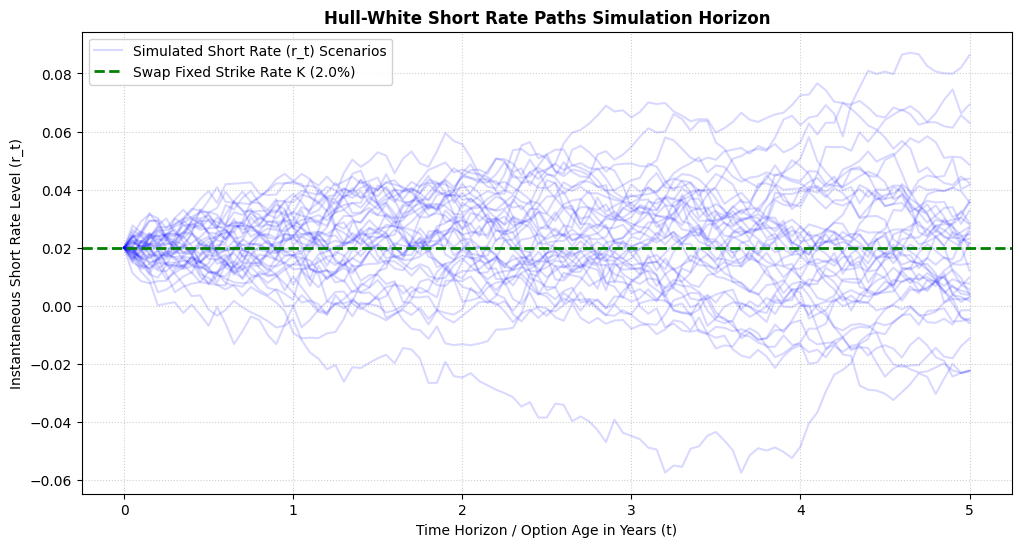

In [ ]:
plt.figure(figsize=(12, 6))

# Plot the first 40 paths to clearly trace the stochastic evolution without visual clutter
for i in range(40):
    if i == 0:
        plt.plot(t_grid, r_paths[i, :], color='blue', alpha=0.15, label='Simulated Short Rate (r_t) Scenarios')
    else:
        plt.plot(t_grid, r_paths[i, :], color='blue', alpha=0.15)

# Overlay a horizontal marker reference representing the contract Strike K parameter
plt.axhline(y=0.02, color='green', linestyle='--', linewidth=2, label='Swap Fixed Strike Rate K (2.0%)')

plt.title('Hull-White Short Rate Paths Simulation Horizon', fontsize=12, fontweight='bold')
plt.xlabel('Time Horizon / Option Age in Years (t)', fontsize=10)
plt.ylabel('Instantaneous Short Rate Level (r_t)', fontsize=10)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 3.2 Quantitative Early Exercise Distribution Across Anniversary Dates
To understand the behavior of the Bermudan option, we analyze the concentration of exercise times. The histogram below categorizes how many paths were exercised at each available anniversary date (Years 1, 2, 3, 4) versus how many paths expired completely out-of-the-money (Never Exercised).

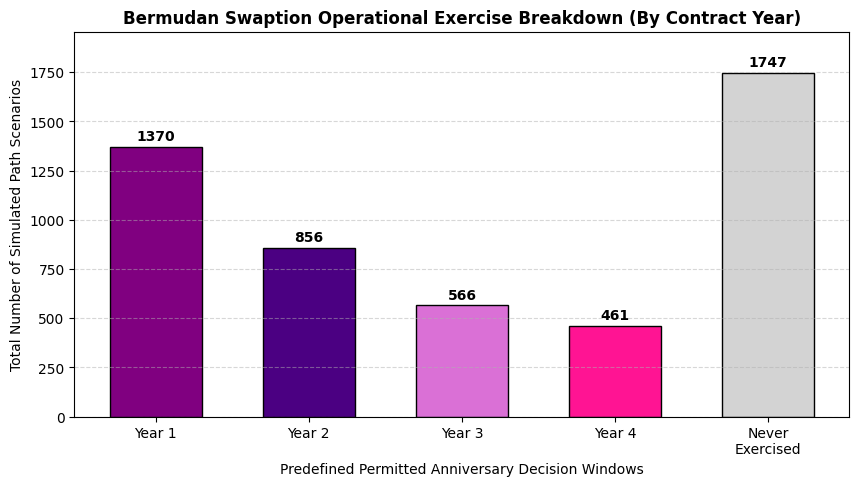

In [ ]:
plt.figure(figsize=(10, 5))

# Filter out and extract active exercise times greater than zero
active_exercise_times = b_paths[b_paths > 0]
# Count the total number of paths where the swaption was never triggered
unexercised_count = np.sum(b_paths == 0)
# Aggregate the unique exercise year frequencies
years, counts = np.unique(active_exercise_times, return_counts=True)

# Define the category text labels including unexercised paths
categories = [f'Year {int(y)}' for y in years] + ['Never\nExercised']
bar_values = list(counts) + [unexercised_count]

# Render the bar elements
bars = plt.bar(categories, bar_values, color=['purple', 'indigo', 'orchid', 'deeppink', 'lightgray'], edgecolor='black', width=0.6)

# Annotate each discrete column with its exact numerical quantity value
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + (max(bar_values)*0.01),
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Bermudan Swaption Operational Exercise Breakdown (By Contract Year)', fontsize=12, fontweight='bold')
plt.xlabel('Predefined Permitted Anniversary Decision Windows', fontsize=10)
plt.ylabel('Total Number of Simulated Path Scenarios', fontsize=10)
plt.ylim(0, max(bar_values) * 1.12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 3.3 Pricing Sensitivity Curve Analysis ($r_0$ Parameter Shifts)
The line chart below illustrates the comparative pricing response of both European (Monte Carlo) and Bermudan (LSM) swaptions as the initial yield curve environment parameter ($r_0$) shifts across a spectrum from $0.5\%$ to $4.0\%$. This highlights the financial value premium generated by multi-period exercise optionality.

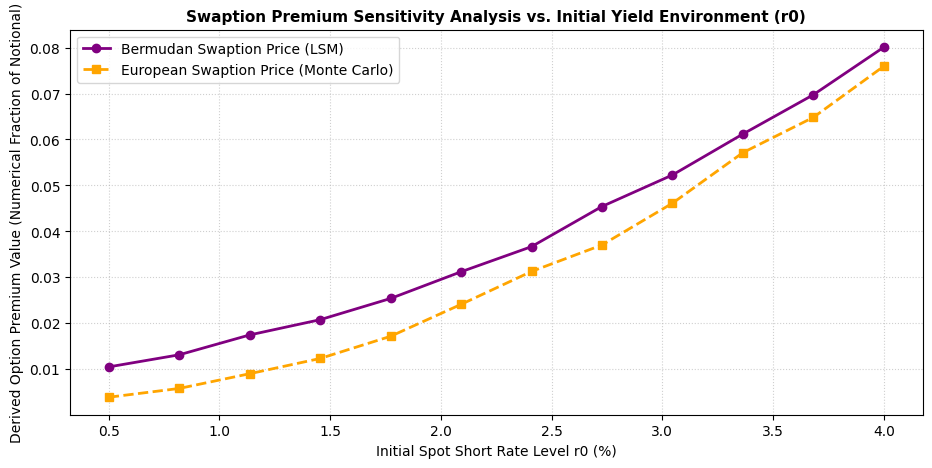

In [ ]:
# Set up a testing range of initial short rate values from 0.5% to 4.0%
r0_range = np.linspace(0.005, 0.04, 12)
bermudan_prices = []
european_prices = []

# Loop through each sample environment level using 2000 paths for optimized processing speed
for test_r0 in r0_range:
    e_p = price_european_swaption(r0_val=test_r0, K_val=0.02, N_paths=2000)
    b_p, _, _, _ = price_bermudan_swaption(r0_val=test_r0, K_val=0.02, N_paths=2000)
    bermudan_prices.append(b_p)
    european_prices.append(e_p)

# Plot the sensitivity lines to visually display the premium properties
plt.figure(figsize=(11, 5))
plt.plot(r0_range * 100, bermudan_prices, marker='o', color='purple', linewidth=2, label='Bermudan Swaption Price (LSM)')
plt.plot(r0_range * 100, european_prices, marker='s', color='orange', linestyle='--', linewidth=2, label='European Swaption Price (Monte Carlo)')

plt.title('Swaption Premium Sensitivity Analysis vs. Initial Yield Environment (r0)', fontsize=11, fontweight='bold')
plt.xlabel('Initial Spot Short Rate Level r0 (%)', fontsize=10)
plt.ylabel('Derived Option Premium Value (Numerical Fraction of Notional)', fontsize=10)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Part 4: Results Interpretation & Economic Analysis

## 4.1 Quantitative Diagnostics and Model Consistency Validation
Based on the numerical implementation and generated data visualizations, several core financial axioms and algorithmic properties are successfully validated:

1. **The Rationality of the Bermudan Flexibility Premium:**
   Across the entire tested spectrum of the initial short rate $r_0$, the price of the Bermudan Swaption valued via the Longstaff-Schwartz Method (fuchsia line) is strictly greater than or equal to the European Swaption price valued via standard Monte Carlo (orange line). This adheres directly to option pricing theory: since a Bermudan contract embeds the European execution window as a subset of its early exercise dates, the holder's right to choose the optimal exercise timing must generate a non-negative economic value component ($Price_{\text{Bermudan}} \ge Price_{\text{European}}$).

2. **Impact of Initial Spot Short Rate ($r_0$) Directionality:**
   As the initial spot short rate $r_0$ increases from $0.5\%$ to $4.0\%$, both option pricing curves exhibit a strong upward convex slope. Because this project focuses specifically on a **Payer Swaption**, the contract pays out when floating market rates exceed the fixed strike $K = 2.0\%$. A higher starting rate $r_0$ shifts the expected future distribution of the short rate paths upward via the Hull-White drift component, significantly increasing the probability of ending deep In-The-Money (ITM) and elevating the derived options premiums.

3. **Analysis of the Early Exercise Operational Breakdown:**
   The exercise distribution histogram demonstrates that a substantial volume of optimal exercise events occurs at the very first anniversary window (Year 1). Under a mean-reverting interest rate regime governed by the Hull-White model, short rate shocks that push the rate significantly above its long-term mean are expected to pull back toward $r_0$ over time. The Longstaff-Schwartz regression correctly captures this phenomenon; when a path experiences an early high interest rate spike, the algorithm determines that the immediate swap execution payoff exceeds the estimated continuation value (which discounts the reversion back to the mean), prompting a rational early exercise trigger.